In [3]:
import sys
import os

# Ова ја додава главната папка 'Stock-Price-Prediction' во системот
# за да може да ја види папката 'src'
sys.path.append(os.path.abspath(".."))

# Проверка: Ова треба да ја испечати патеката до твојот главен фолдер
print(os.path.abspath(".."))

c:\Users\PC\Desktop\stock_price_prediction\Stock-Price-Prediction


MAE Резултати: {'Random Forest': 0.016839713191457665, 'KNN': 0.024109303064359745, 'SVM': 0.045935461211697934, 'XGBoost': 0.016702010068896083}


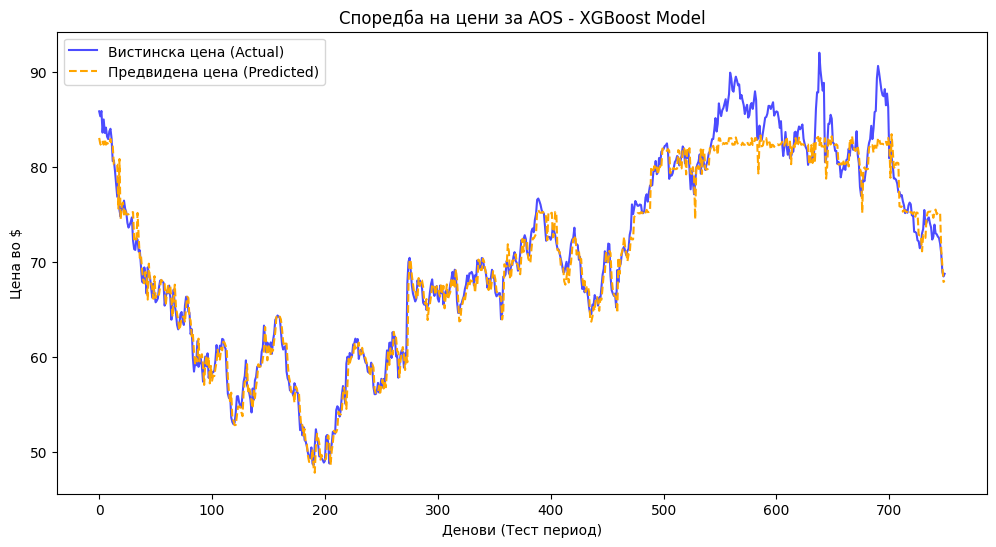

In [4]:
from src.preprocessing import load_and_clean_data, scale_data, split_data
from src.features import create_features
from src.train import get_trained_models
from src.evaluate import evaluate_models, plot_predictions

# Извршување на целиот процес
df = load_and_clean_data('../data/raw/sp500_stocks.csv', symbol="AOS")
df_ready = create_features(df)

features_list = ['Close', 'MA7', 'MA21', 'Daily_Return', 'Volatility']
df_scaled, scaler, t_scaler = scale_data(df_ready, features_list)

train, test = split_data(df_scaled)
X_train, y_train = train[features_list], train['Target']
X_test, y_test = test[features_list], test['Target']

# Ова ќе ги тренира сите модели одеднаш
trained_models = get_trained_models(X_train, y_train)

# Евалуација
results = evaluate_models(trained_models, X_test, y_test)
print("MAE Резултати:", results)

# Нацртај го победникот (XGBoost)
plot_predictions(y_test, trained_models["XGBoost"].predict(X_test), t_scaler, "AOS")

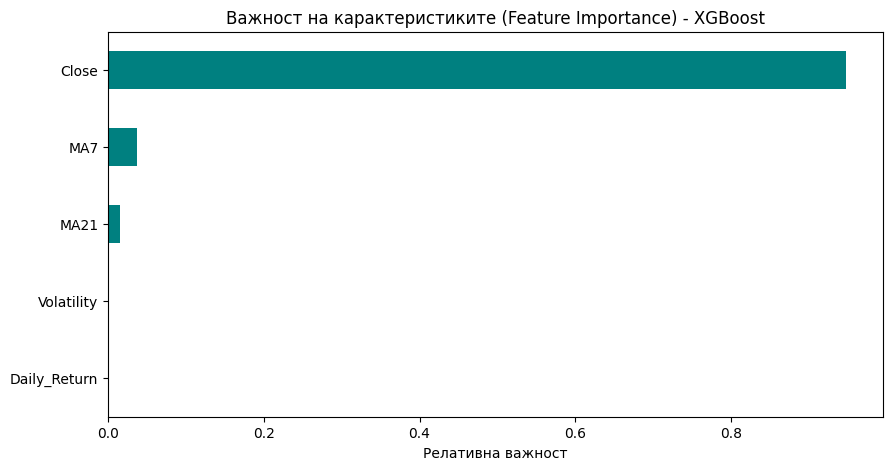

In [5]:
from src.evaluate import plot_feature_importance

# Прикажи кои features се најважни
best_model = trained_models["XGBoost"]
plot_feature_importance(best_model, features_list)

In [6]:
# Ги исфрламе Volatility и Daily_Return бидејќи се бескорисни на графикот
features_list_optimized = ['Close', 'MA7', 'MA21']

# Го менуваме сетот на податоци за тренирање
X_train_opt = train[features_list_optimized]
X_test_opt = test[features_list_optimized]

# Повторно го тренираме само XGBoost со новите чисти колони
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

optimized_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
optimized_model.fit(X_train_opt, y_train)

# Мериме нова грешка
opt_preds = optimized_model.predict(X_test_opt)
new_error = mean_absolute_error(y_test, opt_preds)

print(f"Стара MAE грешка (со сите 5 колони): 0.016702")
print(f"Нова MAE грешка (со 3 чисти колони): {new_error:.6f}")

Стара MAE грешка (со сите 5 колони): 0.016702
Нова MAE грешка (со 3 чисти колони): 0.017004


In [7]:
# Оптимизација на XGBoost параметрите со чистите колони
tuned_model = XGBRegressor(
    n_estimators=200,       # Зголемуваме број на дрва (од 100 на 200) за подлабоко учење
    learning_rate=0.02,     # Ја намалуваме брзината на учење (од 0.05 на 0.02) за поголема прецизност
    max_depth=4,            # Го ограничуваме разгранувањето за да спречиме Overfitting
    random_state=42
)

# Тренирање на подобрениот модел
tuned_model.fit(X_train_opt, y_train)

# Мерење на финалната грешка
tuned_preds = tuned_model.predict(X_test_opt)
tuned_error = mean_absolute_error(y_test, tuned_preds)

print(f"Стара MAE грешка (5 колони): 0.016702")
print(f"Нова MAE грешка (3 колони, Оптимизиран модел): {tuned_error:.6f}")

Стара MAE грешка (5 колони): 0.016702
Нова MAE грешка (3 колони, Оптимизиран модел): 0.018456
